In [1]:
import seaborn as sns
import pandas as pd
import json
import os
import re
sns.set_style('darkgrid')

In [2]:
src_dir = '../../models/eye_gaze_finetuning/'
model_dirs = [os.path.join(src_dir, model_name) for model_name in os.listdir(src_dir) if '_50epochs' in model_name]

In [3]:
def load_trainer_state(model_dir):
    trainer_state_path = os.path.join(model_dir, 'trainer_state.json')
    with open(trainer_state_path, 'r') as src_file:
        trainer_state = json.load(src_file)
    return trainer_state

In [4]:
trainer_states = {}
for model_dir in model_dirs:
    try:
        trainer_states[model_dir] = load_trainer_state(model_dir)
    except:
        pass

In [5]:
def parse_log_history_loss(log_history):
    logs_dict = {'epoch': [], 'data':[], 'loss':[]}
    for el in log_history:
        if 'loss' in el:
            logs_dict['epoch'].append(el['epoch'])
            logs_dict['data'].append('train')
            logs_dict['loss'].append(el['loss'])
        else:
            if 'eval_loss' in el:
                logs_dict['epoch'].append(el['epoch'])
                logs_dict['data'].append('eval')
                logs_dict['loss'].append(el['eval_loss'])
    return pd.DataFrame.from_dict(logs_dict)

In [6]:
loss_dfs = []
for model_dir, trainer_state in trainer_states.items():
    lr = re.findall(r'_lr(.*)$', model_dir)[0]
    loss_df = parse_log_history_loss(trainer_state['log_history'])
    loss_df['learning_rate'] = lr
    loss_dfs.append(loss_df)

In [7]:
loss_dfs = pd.concat(loss_dfs, axis=0)

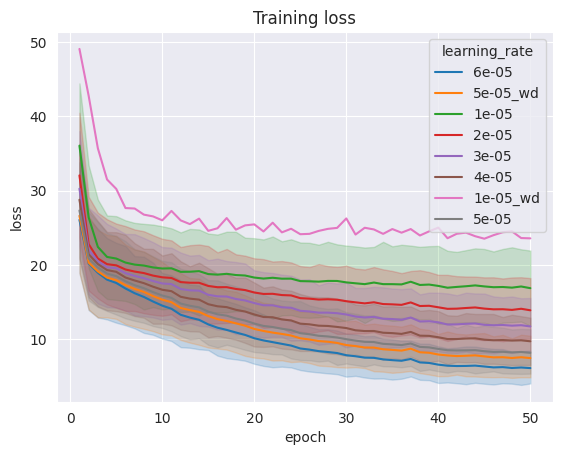

In [8]:
sns.lineplot(data=loss_dfs[loss_dfs['data']=='train'], x='epoch', y='loss', hue='learning_rate').set_title('Training loss');

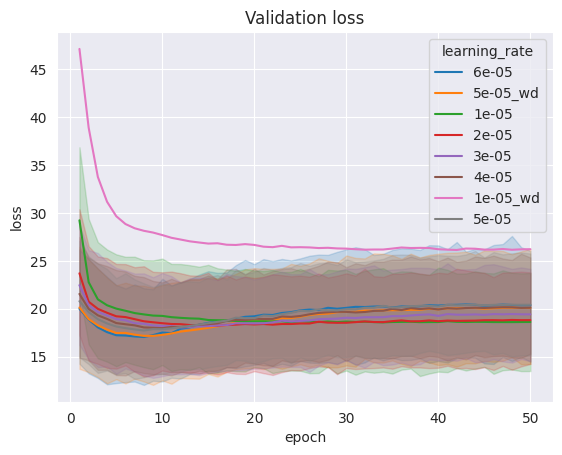

In [9]:
sns.lineplot(data=loss_dfs[loss_dfs['data']=='eval'], x='epoch', y='loss', hue='learning_rate').set_title('Validation loss');

In [10]:
def parse_log_history_eval_metrics(log_history):
    logs_dict = {'epoch': [], 'metric':[], 'score':[], 'label':[]}
    for el in log_history:
        if 'eval_loss' in el:
            epoch = el['epoch']
            for k, v in el.items():
                if k.startswith('eval_label_'):
                    label = k[len('eval_label_'):]
                    for metric, score in v.items():
                        logs_dict['epoch'].append(epoch)
                        logs_dict['label'].append(label)
                        logs_dict['metric'].append(metric)
                        logs_dict['score'].append(score)
    return pd.DataFrame.from_dict(logs_dict)

In [11]:
metrics_dfs = []
for model_dir, trainer_state in trainer_states.items():
    lr = re.findall(r'_lr(.*)$', model_dir)[0]
    metrics_df = parse_log_history_eval_metrics(trainer_state['log_history'])
    metrics_df['learning_rate'] = lr
    metrics_dfs.append(metrics_df)
metrics_dfs = pd.concat(metrics_dfs, axis=0)

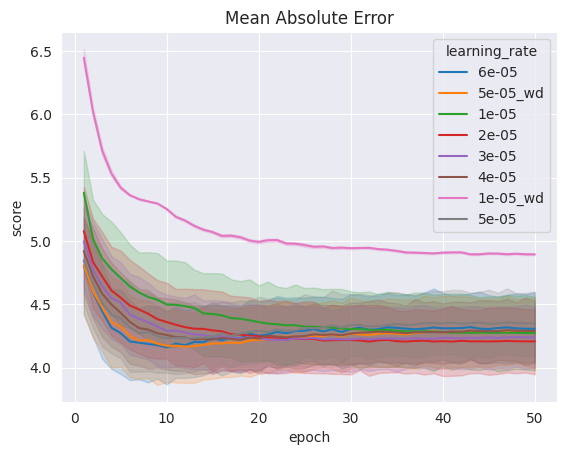

In [12]:
sns.lineplot(data=metrics_dfs[metrics_dfs['metric']=='mae'], x='epoch', y='score', hue='learning_rate').set_title('Mean Absolute Error');

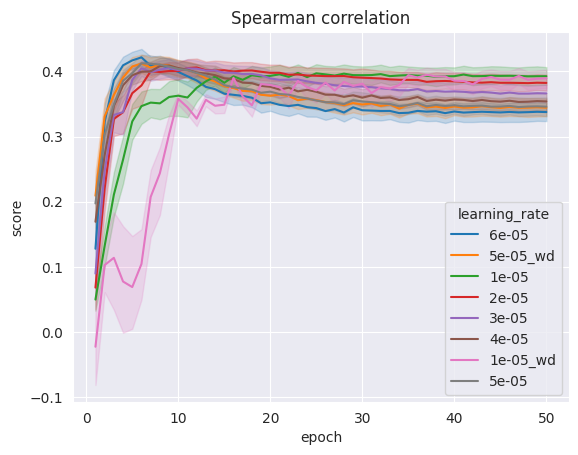

In [13]:
sns.lineplot(data=metrics_dfs[metrics_dfs['metric']=='spearmanr'], x='epoch', y='score', hue='learning_rate').set_title('Spearman correlation');